# Notebook 2: Data Preprocessing
**Steam Sales Prediction — CIS 5450 Final Project**

Goals
─────
Walk through each preprocessing step in `src/data/preprocessor.py`,
inspect the result, and verify the final feature set is clean and ready
for modelling.

## 0. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from configs.config import RAW_MERGED_PATH, OUTPUT_DIR
from src.data.loader import load_merged, validate_merged
from src.data.preprocessor import (
    run_preprocessing_pipeline,
    audit_columns,
    PUBLISHER_CLASS_ORDER,
)
from src.features.engineer import prepare_features, get_feature_columns

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## 1. Load raw data

In [2]:
df_raw = load_merged(RAW_MERGED_PATH, verbose=True)
validate_merged(df_raw)
print(f"Raw shape: {df_raw.shape}")

copiesSold has 98 null values — check the merge.



  games_merged.csv
  Rows: 115,289   Columns: 47

  Columns with >10% nulls:
    Movies                              100.0%
    Score rank                          100.0%
    Metacritic url                      96.4%
    Reviews                             89.6%
    Notes                               79.9%
    Website                             57.6%
    Support url                         53.5%
    Tags                                29.8%
    Support email                       12.0%

Raw shape: (115289, 47)


## 2. Run the full preprocessing pipeline

This calls all steps in order.  Set `verbose=True` to see each step logged.

In [3]:
df = run_preprocessing_pipeline(df_raw, post_release=False, verbose=True)
print(f"\nProcessed shape: {df.shape}")


Processed shape: (115191, 84)


In [4]:
df.columns

Index(['AppID', 'Name', 'copiesSold', 'Required age', 'Price', 'Discount',
       'DLC count', 'Windows', 'Mac', 'Linux', 'Achievements', 'earlyAccess',
       'release_year', 'release_month', 'release_quarter', 'game_age',
       'language_count', 'genre_action', 'genre_adventure', 'genre_casual',
       'genre_early_access', 'genre_free_to_play', 'genre_indie',
       'genre_massively_multiplayer', 'genre_rpg', 'genre_racing',
       'genre_simulation', 'genre_sports', 'genre_strategy', 'genre_violent',
       'genre_sexual_content', 'genre_gore', 'has_singleplayer',
       'has_multiplayer', 'has_coop', 'has_vr', 'has_controller',
       'has_achievements', 'has_trading_cards', 'has_workshop',
       'has_family_sharing', 'has_cloud_saves', 'has_leaderboards',
       'has_remote_play', 'tag_count', 'tag_singleplayer', 'tag_indie',
       'tag_action', 'tag_casual', 'tag_adventure', 'tag_2d', 'tag_3d',
       'tag_strategy', 'tag_simulation', 'tag_puzzle', 'tag_atmospheric',
       '

In [18]:
pd.set_option("display.max_columns", None)
df.head(5)

,AppID,Name,copiesSold,Peak CCU,Required age,Price,Discount,DLC count,Windows,Mac,Linux,Metacritic score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,earlyAccess,reviewScore,release_year,release_month,release_quarter,language_count,estimated_owners_midpoint,genre_action,genre_adventure,genre_casual,genre_early_access,genre_free_to_play,genre_indie,genre_massively_multiplayer,genre_rpg,genre_racing,genre_simulation,genre_sports,genre_strategy,genre_violent,genre_sexual_content,genre_gore,has_singleplayer,has_multiplayer,has_coop,has_vr,has_controller,has_achievements,has_trading_cards,has_workshop,has_family_sharing,has_cloud_saves,has_leaderboards,has_remote_play,tag_count,tag_singleplayer,tag_indie,tag_action,tag_casual,tag_adventure,tag_2d,tag_3d,tag_strategy,tag_simulation,tag_puzzle,tag_atmospheric,tag_rpg,tag_colorful,tag_pixel_graphics,tag_story_rich,tag_exploration,tag_cute,tag_first_person,tag_arcade,tag_fantasy,tag_early_access,tag_multiplayer,tag_funny,tag_horror,tag_action_adventure,tag_retro,tag_shooter,tag_relaxing,tag_family_friendly,tag_platformer,total_reviews,review_ratio,is_free_to_play,platform_count,description_length,required_age_flag,has_dlc,has_metacritic,publisher_class_ord,developer_freq,publisher_freq,log_copies_sold
0,1635980,Kubinashi Recollection,2637.0,0.0,0,2.564180,0,0.693147,1,0,0,0.0,5.099866,2.197225,3.713572,5.068904,0.000000,0.0,0.000000,0.0,0,95.0,2021,12,4,3,9.210441,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,1,0,14,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,5.147494,0.9477,0,1,1297,0,1,0,1,1,32,7.877776
1,3337970,Coffee Beans,36.0,0.0,0,0.524729,0,0.000000,1,0,0,0.0,0.693147,0.693147,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0,50.0,2024,11,4,1,9.210441,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,8,1,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.098612,0.3333,0,1,388,0,0,0,1,95,90,3.610918
2,1470270,Powerboat VR,741.0,0.0,0,2.995232,0,0.000000,1,0,0,0.0,2.833213,1.945910,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1,74.0,2020,12,4,1,9.210441,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,20,1,1,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,3.135494,0.6957,0,1,3499,0,0,0,1,2,2,6.609349
3,682780,Breaking Good,5409.0,0.0,0,1.098612,0,0.000000,1,1,1,0.0,4.941642,2.944439,4.510859,4.736198,4.644391,0.0,4.644391,0.0,0,88.0,2017,8,3,31,10.463132,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,1,0,15,1,1,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,5.062595,0.8797,0,3,1720,0,0,0,0,2,2,8.596004
4,3674050,Silly's Gameshow,96747.0,0.0,0,0.000000,0,0.000000,1,0,0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0,69.0,2025,6,2,1,0.000000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.0000,1,1,502,0,0,0,0,2,1,11.479865


## 3. Column audit

In [5]:
audit = audit_columns(df)
print(audit.to_string(index=False))

                     column   dtype  null_pct  nunique                 sample
                      AppID   int64       0.0   115191                1635980
             tag_simulation    int8       0.0        2                      0
                   tag_cute    int8       0.0        2                      1
            tag_exploration    int8       0.0        2                      0
             tag_story_rich    int8       0.0        2                      0
         tag_pixel_graphics    int8       0.0        2                      1
               tag_colorful    int8       0.0        2                      0
                    tag_rpg    int8       0.0        2                      0
            tag_atmospheric    int8       0.0        2                      0
                 tag_puzzle    int8       0.0        2                      1
               tag_strategy    int8       0.0        2                      0
                       Name  object       0.0   114165 Kubinashi

## 4. Verify parsed columns

In [6]:
# 4a. Release date
print("release_year  sample:", df["release_year"].dropna().value_counts().sort_index().tail(10))
print("release_month sample:", df["release_month"].value_counts().sort_index())

release_year  sample: release_year
2017     5571
2018     7099
2019     7107
2020     8745
2021    10305
2022    11486
2023    13027
2024    17368
2025    20251
2026     4194
Name: count, dtype: Int64
release_month sample: release_month
1      9074
2      9689
3     10092
4      8764
5      9180
6      8526
7      9461
8      9713
9      9285
10    11010
11    10621
12     9776
Name: count, dtype: Int64


In [7]:
# 4a-bis. Game age (REFERENCE_YEAR=2026 minus release_year)
print("game_age summary:")
print(df["game_age"].describe())
print("\ngame_age distribution (top 15):")
print(df["game_age"].value_counts().sort_index().head(15))
print("\nMean log_copies_sold by game_age (sanity check — expect older games to skew higher):")
print(df.groupby("game_age")["log_copies_sold"].mean().head(15))

game_age summary:
count    115191.0
mean     4.482902
std       3.33285
min           0.0
25%           2.0
50%           4.0
75%           7.0
max          28.0
Name: game_age, dtype: Float64

game_age distribution (top 15):
game_age
0      4194
1     20251
2     17368
3     13027
4     11486
5     10305
6      8745
7      7107
8      7099
9      5571
10     4074
11     2516
12     1583
13      543
14      354
Name: count, dtype: Int64

Mean log_copies_sold by game_age (sanity check — expect older games to skew higher):
game_age
0      4.735334
1      5.312736
2      5.769628
3      6.001680
4      6.315474
5      6.415629
6      6.635583
7      6.634077
8      7.079710
9      7.765616
10     8.655860
11     9.240925
12    10.148699
13    11.496278
14    11.029089
Name: log_copies_sold, dtype: float32


In [8]:
# 4b. Language count
print("language_count distribution:")
print(df["language_count"].value_counts().sort_index().head(20))

language_count distribution:
language_count
0       124
1     59848
2     14736
3      5728
4      4106
5      3700
6      2969
7      2559
8      2544
9      2583
10     2478
11     2200
12     1915
13     1410
14     1063
15      755
16      522
17      334
18      285
19      198
Name: count, dtype: int64


In [9]:
# 4c. Genre binary columns
genre_cols = [c for c in df.columns if c.startswith("genre_")]
print("Genre columns created:", genre_cols)
df[genre_cols].sum().sort_values(ascending=False)

Genre columns created: ['genre_action', 'genre_adventure', 'genre_casual', 'genre_early_access', 'genre_free_to_play', 'genre_indie', 'genre_massively_multiplayer', 'genre_rpg', 'genre_racing', 'genre_simulation', 'genre_sports', 'genre_strategy', 'genre_violent', 'genre_sexual_content', 'genre_gore']


genre_indie                    82702
genre_casual                   51484
genre_action                   47011
genre_adventure                46096
genre_simulation               24744
genre_strategy                 22954
genre_rpg                      21400
genre_early_access             11010
genre_sports                    4907
genre_racing                    4147
genre_massively_multiplayer     2463
genre_violent                    393
genre_gore                       240
genre_sexual_content              86
genre_free_to_play                 0
dtype: int64

In [10]:
# 4d. Category binary flags
cat_cols = [c for c in df.columns if c.startswith("has_")]
print("Category/feature flags:")
df[cat_cols].sum().sort_values(ascending=False)

Category/feature flags:


has_singleplayer      110553
has_family_sharing     98157
has_achievements       57338
has_controller         44611
has_cloud_saves        31399
has_multiplayer        20454
has_dlc                18024
has_trading_cards      11278
has_coop               11159
has_remote_play         9736
has_leaderboards        9399
has_vr                  6351
has_workshop            2537
dtype: int64

In [11]:
# 4e. Tag columns
tag_cols = [c for c in df.columns if c.startswith("tag_")]
print(f"Number of tag binary columns: {len(tag_cols)}")
df[tag_cols].sum().sort_values(ascending=False).head(20)

Number of tag binary columns: 31


tag_count             1160550
tag_singleplayer        49745
tag_indie               47848
tag_action              36260
tag_casual              36007
tag_adventure           34742
tag_2d                  26539
tag_3d                  17828
tag_strategy            17565
tag_simulation          17524
tag_puzzle              16198
tag_atmospheric         16057
tag_rpg                 15465
tag_colorful            14131
tag_pixel_graphics      13764
tag_story_rich          13157
tag_exploration         13122
tag_cute                12482
tag_first_person        12132
tag_arcade              11433
dtype: int64

In [12]:
# 4f. Publisher class encoding
print(df["publisher_class_ord"].value_counts().sort_index())
print("Mapping:", PUBLISHER_CLASS_ORDER)

publisher_class_ord
0    64248
1    46369
2     3263
3     1311
Name: count, dtype: int64
Mapping: {'Hobbyist': 0, 'Indie': 1, 'AA': 2, 'AAA': 3}


In [13]:
# 4g. Derived features
derived = [ "is_free_to_play",
           "platform_count", "description_length", "required_age_flag", "has_dlc"]
df[derived].describe()

,is_free_to_play,platform_count,description_length,required_age_flag,has_dlc
count,115191.000000,115191.000000,115191.000000,115191.000000,115191.000000
mean,0.148223,1.324183,1294.891268,0.010331,0.156471
std,0.355323,0.646164,1094.580854,0.101114,0.363302
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,679.000000,0.000000,0.000000
50%,0.000000,1.000000,1065.000000,0.000000,0.000000
75%,0.000000,1.000000,1629.000000,0.000000,0.000000
max,1.000000,3.000000,89665.000000,1.000000,1.000000


## 5. Target variable check

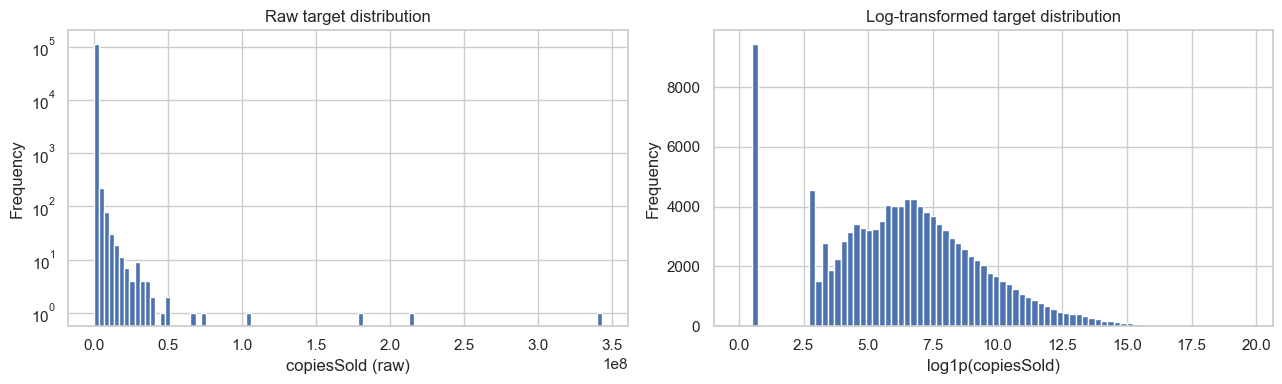

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df["copiesSold"].plot(kind="hist", bins=100, logy=True, ax=axes[0])
axes[0].set_xlabel("copiesSold (raw)")
axes[0].set_title("Raw target distribution")

df["log_copies_sold"].plot(kind="hist", bins=80, ax=axes[1])
axes[1].set_xlabel("log1p(copiesSold)")
axes[1].set_title("Log-transformed target distribution")

plt.tight_layout()
plt.savefig("../outputs/prep_target_comparison.png", dpi=150)
plt.show()

## 6. Feature matrix overview

In [15]:
feature_cols = get_feature_columns(df, post_release=True)
print(f"Total feature columns (post-release): {len(feature_cols)}")

feature_cols_launch = get_feature_columns(df, post_release=False)
print(f"Total feature columns (launch-time): {len(feature_cols_launch)}")

Total feature columns (post-release): 80
Total feature columns (launch-time): 80


In [16]:
# Null counts in feature matrix
X_check = df[feature_cols]
null_summary = X_check.isnull().sum()
print("Null counts per feature column (any > 0 shown):")
print(null_summary[null_summary > 0].sort_values(ascending=False))

Null counts per feature column (any > 0 shown):
Series([], dtype: int64)


## 7. Feature / target correlation (post-release)

In [17]:
corr_with_target = (
    df[feature_cols + ["log_copies_sold"]]
    .select_dtypes(include="number")
    .corr()["log_copies_sold"]
    .drop("log_copies_sold")
    .sort_values(key=abs, ascending=False)
)

print("Top 20 features correlated with log_copies_sold:")
print(corr_with_target.head(20).to_string())

Top 20 features correlated with log_copies_sold:
publisher_class_ord    0.590079
has_trading_cards      0.391773
release_year          -0.379429
game_age               0.379429
DLC count              0.344915
has_dlc                0.337678
Achievements           0.312924
has_cloud_saves        0.255331
has_family_sharing    -0.252653
is_free_to_play        0.244093
tag_count              0.241992
has_achievements       0.241987
tag_multiplayer        0.226190
Mac                    0.160913
tag_story_rich         0.157828
has_multiplayer        0.150604
Required age           0.149610
platform_count         0.149276
required_age_flag      0.147386
tag_adventure          0.146333


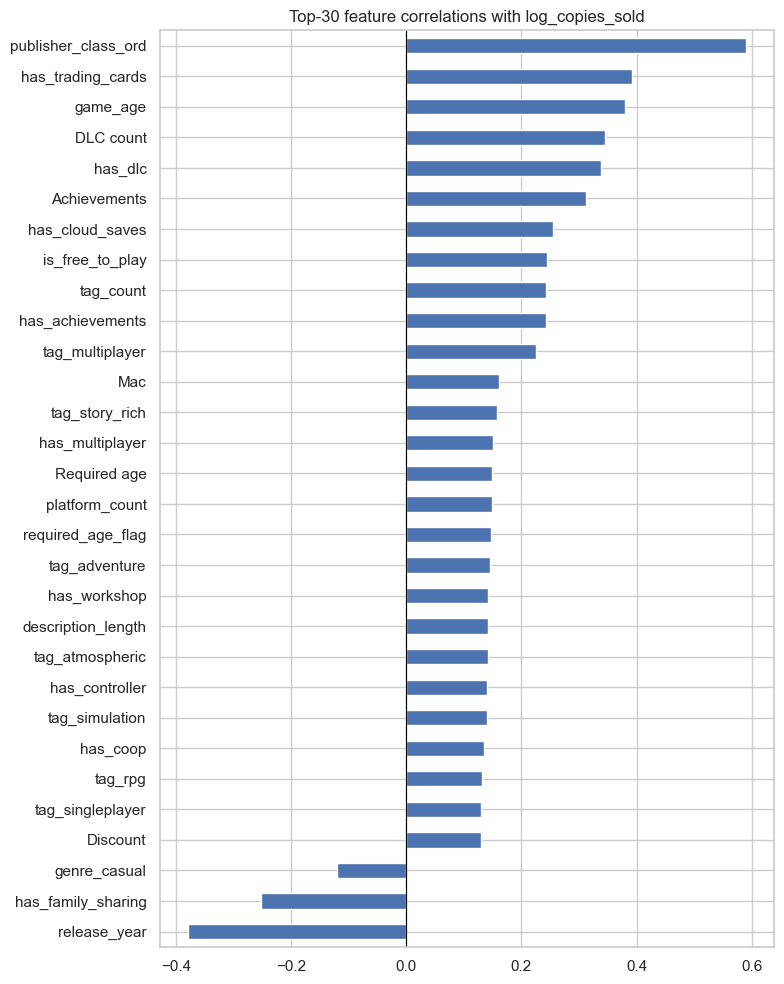

In [18]:
# Visual
fig, ax = plt.subplots(figsize=(8, 10))
corr_with_target.head(30).sort_values().plot(kind="barh", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top-30 feature correlations with log_copies_sold")
plt.tight_layout()
plt.savefig("../outputs/prep_feature_correlation.png", dpi=150)
plt.show()

## 8. Save processed data

In [20]:
df.to_parquet("../outputs/processed.parquet", index=False)
print("Saved → outputs/processed.parquet")

Saved → outputs/processed.parquet


## Summary of preprocessing decisions

| Issue | Decision |
|---|---|
| `copiesSold` extreme right-skew | Use `log1p(copiesSold)` as target |
| `Movies`, `Score rank`, `Reviews`, `Notes` near-entirely null | Dropped |
| `URL` columns (Header image, steamUrl, Screenshots) | Dropped |
| `User score` 99.97 % zero | Dropped |
| `Metacritic score` 96 % zero | Kept; added `has_metacritic` binary flag |
| `Supported languages` list string | Parsed → `language_count` |
| `Genres` / `Categories` / `Tags` comma-separated strings | Parsed → binary columns |
| `Estimated owners` range string | Parsed → midpoint; flagged as post-release |
| `Release date` (two overlapping columns) | Both parsed → `release_year/month/quarter` |
| `Developers`, `Publishers` high cardinality | Frequency-encoded |
| `publisherClass` ordinal | Encoded 0-3 |
| Post-release features (playtime, review counts) | Conditionally excluded via `post_release` flag |